In [250]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import plotly.graph_objects as go
import nbformat
import numpy as np


[INFO]  Data folder ./hibachi_log_2022-06-10-10-58-55 already exists. Not creating.
Index(['Time', 'header.seq', 'header.stamp.secs', 'header.stamp.nsecs',
       'header.frame_id', 'vector.x', 'vector.y', 'vector.z'],
      dtype='str')


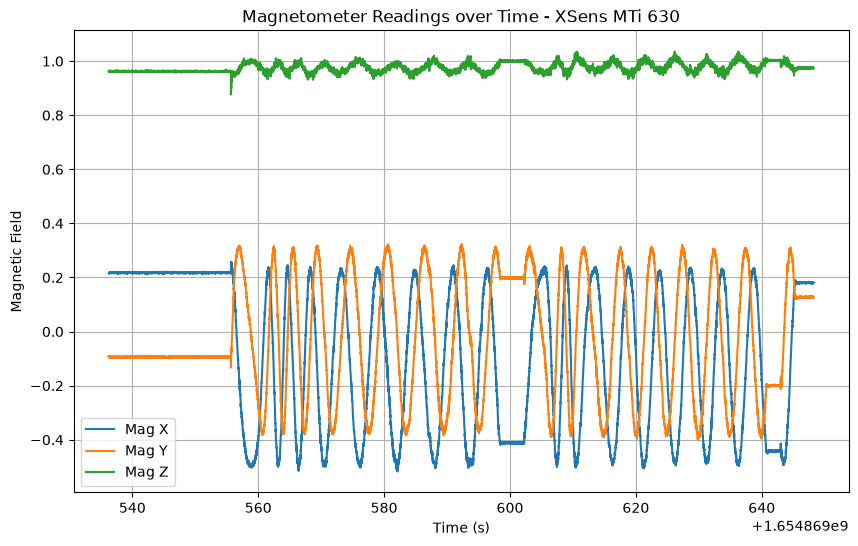

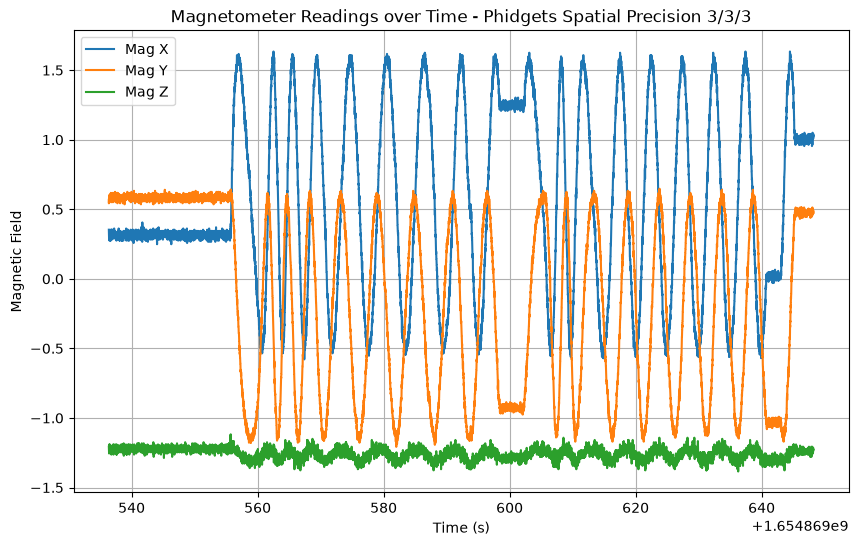

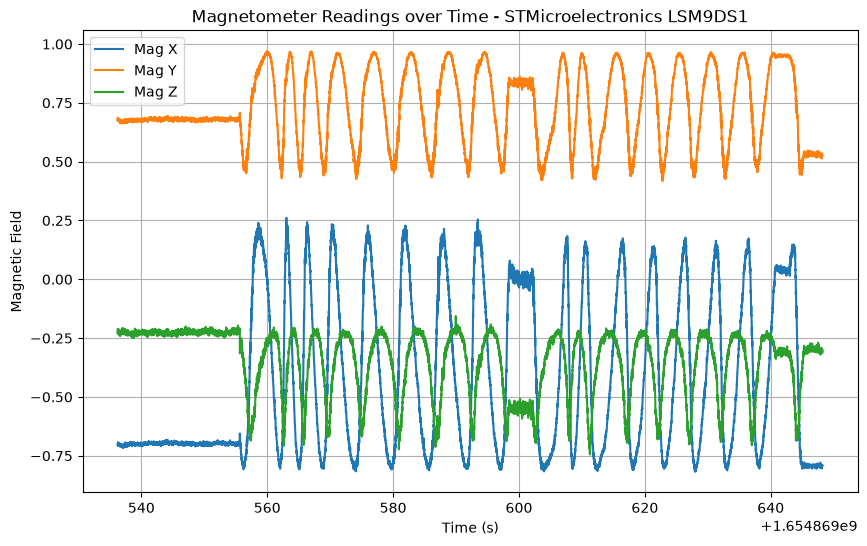

In [251]:
def plot_mag_data(_mag_data, imu_model=None, show=False):

    plot_title = "Magnetometer Readings over Time"
    if imu_model is not None:
        plot_title += " - " + imu_model

    plt.figure(figsize=(10, 6))
    try:        
        plt.plot(_mag_data['Time'], _mag_data['vector.x'], label='Mag X')
        plt.plot(_mag_data['Time'], _mag_data['vector.y'], label='Mag Y')
        plt.plot(_mag_data['Time'], _mag_data['vector.z'], label='Mag Z')
    except KeyError:
        plt.plot(_mag_data['Time'], _mag_data['magnetic_field.x'], label='Mag X')
        plt.plot(_mag_data['Time'], _mag_data['magnetic_field.y'], label='Mag Y')
        plt.plot(_mag_data['Time'], _mag_data['magnetic_field.z'], label='Mag Z')
    plt.xlabel('Time (s)')
    plt.ylabel('Magnetic Field')

    plt.title(plot_title)
    plt.legend()
    plt.grid(True)
    if show:
        plt.show()


# 1. Read the bag file
b = bagreader('./hibachi_log_2022-06-10-10-58-55.bag')

# 2. Get the specific topic's data (saves as a CSV automatically)
# To find your topic names, you can first run: print(b.topic_table)
# print(b.topic_table)

# The magnetometer topics are the following
# /mti_630_8A1G6/imu/mag ---> XSens MTi 630
# /phidgets_373223/imu/mag ---> Phidgets Spatial Precision 3/3/3
# /hibachi_imu_node/mag ---> STMicroelectronics LSM9DS1

mti_630_mag = b.message_by_topic(topic='/mti_630_8A1G6/imu/mag')
phidgets_mag = b.message_by_topic(topic='/phidgets_373223/imu/mag')
lsm9ds1_mag = b.message_by_topic(topic='/hibachi_imu_node/mag')


# 3.1. Load the data into a pandas DataFrame
df0 = pd.read_csv(mti_630_mag)
print(df0.columns)

# 3.2. Plot the data
plot_mag_data(df0, imu_model="XSens MTi 630", show=False)

# 4.1. Load the data into a pandas DataFrame
df1 = pd.read_csv(phidgets_mag)
# Pasar a [G]
df1['magnetic_field.x'] /= 1e-4
df1['magnetic_field.y'] /= 1e-4
df1['magnetic_field.z'] /= 1e-4

# 4.2. Plot the data
plot_mag_data(df1, imu_model="Phidgets Spatial Precision 3/3/3", show=False)

# 5.1. Load the data into a pandas DataFrame
df2 = pd.read_csv(lsm9ds1_mag)
# Pasar a [G]
df2['magnetic_field.x'] /= 1e-4
df2['magnetic_field.y'] /= 1e-4
df2['magnetic_field.z'] /= 1e-4

# 5.2. Plot the data
plot_mag_data(df2, imu_model="STMicroelectronics LSM9DS1", show=True)

## Normalización de los datos (estandarización por eje)

Se estandariza cada eje $x,y,z$ de los tres DataFrames: $x_{\text{norm}}=(x-\mu)/\sigma$. Se guardan $\mu$ y $\sigma$ en `scaler_stats` para poder volver a la escala real con $x = x_{\text{norm}}\,\sigma + \mu$.

In [252]:
# Estandarización de los ejes x, y, z de cada DataFrame.
# Guarda media y desvío para poder volver a la escala real.
scaler_stats = {}   # {nombre: {'cols': [...], 'mean': array, 'std': array}}

for name, df in [('df0', df0), ('df1', df1), ('df2', df2)]:
    # Detecta los nombres de columnas (vector.* o magnetic_field.*)
    if 'vector.x' in df.columns:
        cols = ['vector.x', 'vector.y', 'vector.z']
    else:
        cols = ['magnetic_field.x', 'magnetic_field.y', 'magnetic_field.z']

    mean = df[cols].mean().to_numpy()
    std  = df[cols].std().to_numpy()        # ddof=1 (desvío muestral)

    df[cols] = (df[cols] - mean) / std      # x_norm = (x - media) / desvío

    scaler_stats[name] = {'cols': cols, 'mean': mean, 'std': std}
    print(f"{name}: cols={cols}\n   mean={mean}\n   std ={std}")

# Para volver a la escala real:
#   for name, df in [('df0', df0), ('df1', df1), ('df2', df2)]:
#       s = scaler_stats[name]
#       df[s['cols']] = df[s['cols']] * s['std'] + s['mean']

df0: cols=['vector.x', 'vector.y', 'vector.z']
   mean=[-0.07727835 -0.02517058  0.97584513]
   std =[0.27357421 0.21659638 0.01801636]
df1: cols=['magnetic_field.x', 'magnetic_field.y', 'magnetic_field.z']
   mean=[ 0.54859749 -0.1416705  -1.25718891]
   std =[0.66668264 0.65971712 0.0404368 ]
df2: cols=['magnetic_field.x', 'magnetic_field.y', 'magnetic_field.z']
   mean=[-0.41774313  0.73447692 -0.34644278]
   std =[0.34715041 0.16038703 0.14067408]


# Calibración de magnetómetro por MSE — sistema $H\theta = y$

**Modelo de medición**

$$\mathbf m_c = S_I(\tilde{\mathbf m}-\mathbf b_{HI}), \qquad \|\mathbf m_c\| = h \ \text{(constante)}$$

**Restricción geométrica (elipsoide)**

$$(\tilde{\mathbf m}-\mathbf b_{HI})^TA(\tilde{\mathbf m}-\mathbf b_{HI}) = h^2, \qquad A:=S_I^TS_I$$

**Expansión y reparametrización**

$$\tilde{\mathbf m}^TA\tilde{\mathbf m} - 2\mathbf b_{HI}^TA\tilde{\mathbf m} + \mathbf b_{HI}^TA\mathbf b_{HI} - h^2 = 0$$

$$\mathbf n := -2A\mathbf b_{HI}, \qquad d:=\mathbf b_{HI}^TA\mathbf b_{HI}-h^2 \;\Rightarrow\; \tilde{\mathbf m}^TA\tilde{\mathbf m}+\mathbf n^T\tilde{\mathbf m}+d=0$$

**Forma escalar** ($\tilde{\mathbf m}=(x,y,z)^T$, $A$ simétrica) y **normalización** $d:=-1$:

$$a_{11}x^2+a_{22}y^2+a_{33}z^2+2a_{12}xy+2a_{13}xz+2a_{23}yz+n_1x+n_2y+n_3z = 1$$

**Regresores y parámetros por muestra $i$**

$$\boldsymbol\phi_i=\big[x_i^2,\,y_i^2,\,z_i^2,\,2x_iy_i,\,2x_iz_i,\,2y_iz_i,\,x_i,\,y_i,\,z_i\big]^T\in\mathbb R^9,\qquad
\theta=\big[a_{11},a_{22},a_{33},a_{12},a_{13},a_{23},n_1,n_2,n_3\big]^T\in\mathbb R^9$$

**Sistema apilado y estimador MSE**

$$H=\begin{bmatrix}\boldsymbol\phi_1^T\\\vdots\\\boldsymbol\phi_N^T\end{bmatrix}\in\mathbb R^{N\times9},\qquad y=\mathbf 1_N,\qquad H\theta=y$$

$$J(\theta)=\tfrac1N\|H\theta-y\|^2 \;\Rightarrow\; \hat\theta=(H^TH)^{-1}H^Ty$$

**Recuperación de parámetros físicos**

$$\hat A \leftarrow \hat\theta_{1:6},\quad \hat{\mathbf n}\leftarrow\hat\theta_{7:9},\qquad
\hat{\mathbf b}_{HI}=-\tfrac12\hat A^{-1}\hat{\mathbf n}, \qquad \hat h^2=\hat{\mathbf b}_{HI}^T\hat A\hat{\mathbf b}_{HI}+1$$

$$\hat A=R\Lambda R^T \ (\text{eigendescomposición}) \;\Rightarrow\; \hat S_I=\Lambda^{1/2}R^T$$

> En las secciones siguientes se **reescriben las fórmulas en cada caso** (sin definir funciones), una por sensor.

# Parte 1 — MSE 3D sobre datos normalizados (sin PCA)

Las tres secciones siguientes ajustan el **elipsoide 3D** (9 parámetros) directamente sobre los datos ya normalizados (`scaler_stats` permite volver a la escala real).

## Sección 1 — XSens MTi 630 (`df0`)

Se arma $H\theta=y$ con $y=\mathbf 1_N$, se resuelve por MSE $\hat\theta=(H^TH)^{-1}H^Ty$ y se recuperan $\hat A,\ \hat{\mathbf n},\ \hat{\mathbf b}_{HI},\ \hat h,\ \hat S_I$.

In [253]:
# ===================== Sección 1: XSens MTi 630 =====================
# Mediciones crudas  m~ = (x, y, z)
try:
    M = df0[['vector.x', 'vector.y', 'vector.z']].to_numpy()
except KeyError:
    M = df0[['magnetic_field.x', 'magnetic_field.y', 'magnetic_field.z']].to_numpy()

x, y, z = M[:, 0], M[:, 1], M[:, 2]

# Vector de regresores  phi_i = [x², y², z², 2xy, 2xz, 2yz, x, y, z]  ->  H (N x 9)
H = np.column_stack([x**2, y**2, z**2, 2*x*y, 2*x*z, 2*y*z, x, y, z])
yv = np.ones(H.shape[0])                       # y = 1_N

# Estimador MSE:  theta_hat = (H^T H)^{-1} H^T y
theta = np.linalg.inv(H.T @ H) @ H.T @ yv
a11, a22, a33, a12, a13, a23, n1, n2, n3 = theta

# Recuperación de parámetros físicos
A = np.array([[a11, a12, a13],
              [a12, a22, a23],
              [a13, a23, a33]])               # A_hat <- theta_1:6  (simétrica)
n = np.array([n1, n2, n3])                     # n_hat <- theta_7:9

b_HI = -0.5 * np.linalg.inv(A) @ n             # b_HI = -1/2 A^{-1} n   (Hard-Iron)
h2   = b_HI @ A @ b_HI + 1.0                   # h² = b_HI^T A b_HI + 1   (d = -1)
h    = np.sqrt(abs(h2))
#me hace falta calcular S


eigval, R = np.linalg.eigh(A)

if np.any(eigval <= 0):
    print("❌ ERROR CRÍTICO: A no es definida positiva. Los datos son planos o están corruptos.")
    print("Autovalores detectados:", eigval)
    # Forzamos un fallback para que el código no explote (opcional)
    eigval = np.abs(eigval)

# La calibración real utiliza el RECÍPROCO (1 / sqrt(lambda)) para normalizar los ejes
S_I = np.diag(np.sqrt(np.abs(eigval))) @ R.T

# Mediciones calibradas
Mc = (S_I @ (M - b_HI).T).T

❌ ERROR CRÍTICO: A no es definida positiva. Los datos son planos o están corruptos.
Autovalores detectados: [-0.00723058  0.40238128  0.5946    ]


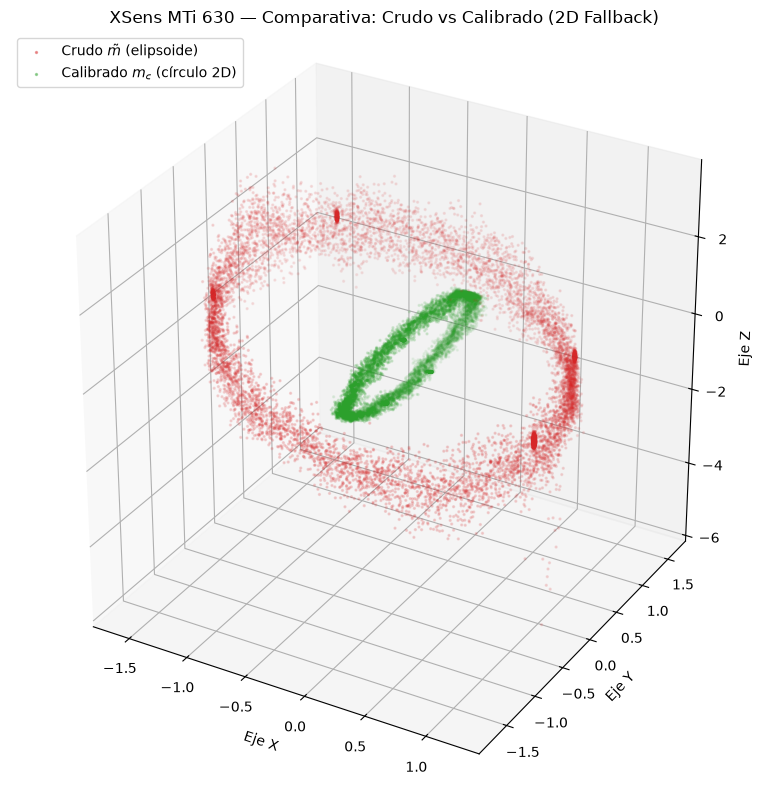

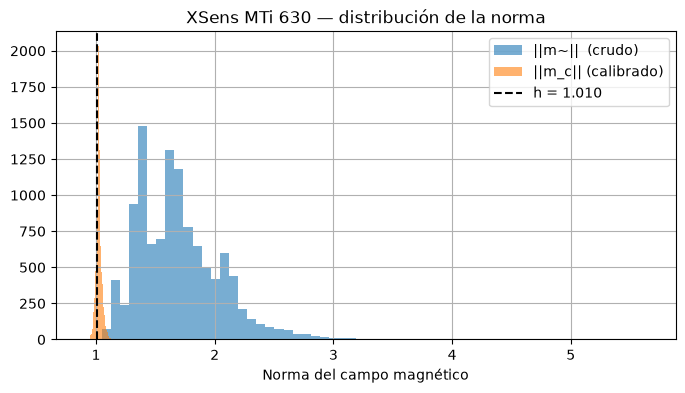

In [254]:
# Creamos una figura con un único eje 3D
fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(1, 1, 1, projection='3d')

# 1. Graficamos los datos crudos (rojo)
ax1.scatter(M[:, 0], M[:, 1], M[:, 2], s=2, alpha=0.4, c='tab:red', label="Crudo $\\tilde{m}$ (elipsoide)")

# 2. Graficamos los datos calibrados en el mismo eje (verde)
ax1.scatter(Mc[:, 0], Mc[:, 1], Mc[:, 2], s=2, alpha=0.4, c='tab:green', label="Calibrado $m_c$ (círculo 2D)")

# Configuración de etiquetas y títulos
ax1.set_title("XSens MTi 630 — Comparativa: Crudo vs Calibrado (2D Fallback)")
ax1.set_xlabel("Eje X")
ax1.set_ylabel("Eje Y")
ax1.set_zlabel("Eje Z")

# Añadimos la leyenda para identificar cada uno
ax1.legend(loc="upper left")

# CRUCIAL para evitar distorsiones ópticas: fuerza a que las escalas X, Y, Z sean proporcionales
ax1.set_box_aspect([1, 1, 1]) 

plt.tight_layout()
plt.show()

# Norma antes/después: debe pasar de variable a ~constante = h
plt.figure(figsize=(8, 4))
plt.hist(np.linalg.norm(M, axis=1),  bins=60, alpha=0.6, label="||m~||  (crudo)")
plt.hist(np.linalg.norm(Mc, axis=1), bins=60, alpha=0.6, label="||m_c|| (calibrado)")
plt.axvline(h, color='k', ls='--', label="h = %.3f" % h)
plt.title("XSens MTi 630 — distribución de la norma")
plt.xlabel("Norma del campo magnético"); plt.legend(); plt.grid(True); plt.show()

## Sección 2 — Phidgets Spatial Precision 3/3/3 (`df1`)

Mismo procedimiento sobre los datos del Phidgets (ya convertidos a $[G]$): se reescriben las fórmulas $H\theta=y \Rightarrow \hat\theta=(H^TH)^{-1}H^Ty$ y se recuperan $\hat{\mathbf b}_{HI},\ \hat h,\ \hat S_I$.

In [255]:
# ============ Sección 2: Phidgets Spatial Precision 3/3/3 ============
# Mediciones crudas  m~ = (x, y, z)
try:
    M = df1[['vector.x', 'vector.y', 'vector.z']].to_numpy()
except KeyError:
    M = df1[['magnetic_field.x', 'magnetic_field.y', 'magnetic_field.z']].to_numpy()

x, y, z = M[:, 0], M[:, 1], M[:, 2]

# Vector de regresores  phi_i = [x², y², z², 2xy, 2xz, 2yz, x, y, z]  ->  H (N x 9)
H = np.column_stack([x**2, y**2, z**2, 2*x*y, 2*x*z, 2*y*z, x, y, z])
yv = np.ones(H.shape[0])                       # y = 1_N

# Estimador MSE:  theta_hat = (H^T H)^{-1} H^T y
theta = np.linalg.inv(H.T @ H) @ H.T @ yv
a11, a22, a33, a12, a13, a23, n1, n2, n3 = theta

# Recuperación de parámetros físicos
A = np.array([[a11, a12, a13],
              [a12, a22, a23],
              [a13, a23, a33]])               # A_hat <- theta_1:6  (simétrica)
n = np.array([n1, n2, n3])                     # n_hat <- theta_7:9

b_HI = -0.5 * np.linalg.inv(A) @ n             # b_HI = -1/2 A^{-1} n   (Hard-Iron)
h2   = b_HI @ A @ b_HI + 1.0                   # h² = b_HI^T A b_HI + 1   (d = -1)
h    = np.sqrt(abs(h2))

eigval, R = np.linalg.eigh(A)

if np.any(eigval <= 0):
    print("❌ ERROR CRÍTICO: A no es definida positiva. Los datos son planos o están corruptos.")
    print("Autovalores detectados:", eigval)
    # Forzamos un fallback para que el código no explote (opcional)
    eigval = np.abs(eigval)

# La calibración real utiliza el RECÍPROCO (1 / sqrt(lambda)) para normalizar los ejes
#S_I = R @ np.diag(1.0 / np.sqrt(eigval)) @ R.T
S_I = np.diag(np.sqrt(np.abs(eigval))) @ R.T

# Mediciones calibradas
Mc = (S_I @ (M - b_HI).T).T

print("Phidgets Spatial Precision 3/3/3")
print("b_HI (hard-iron) =", b_HI)
print("h (radio)        =", h)
print("S_I (soft-iron)  =\n", S_I)
print("||m_c|| medio = %.4f   std = %.4f" % (np.linalg.norm(Mc, axis=1).mean(),
                                             np.linalg.norm(Mc, axis=1).std()))


Phidgets Spatial Precision 3/3/3
b_HI (hard-iron) = [-0.01725496 -0.20054314  2.1850493 ]
h (radio)        = 1.0192164963400923
S_I (soft-iron)  =
 [[ 4.91202183e-04  1.75581037e-04  5.05706063e-02]
 [-6.34980377e-01  7.92958101e-02  5.89237363e-03]
 [-9.55074766e-02 -7.65065539e-01  3.58398871e-03]]
||m_c|| medio = 1.0178   std = 0.0235


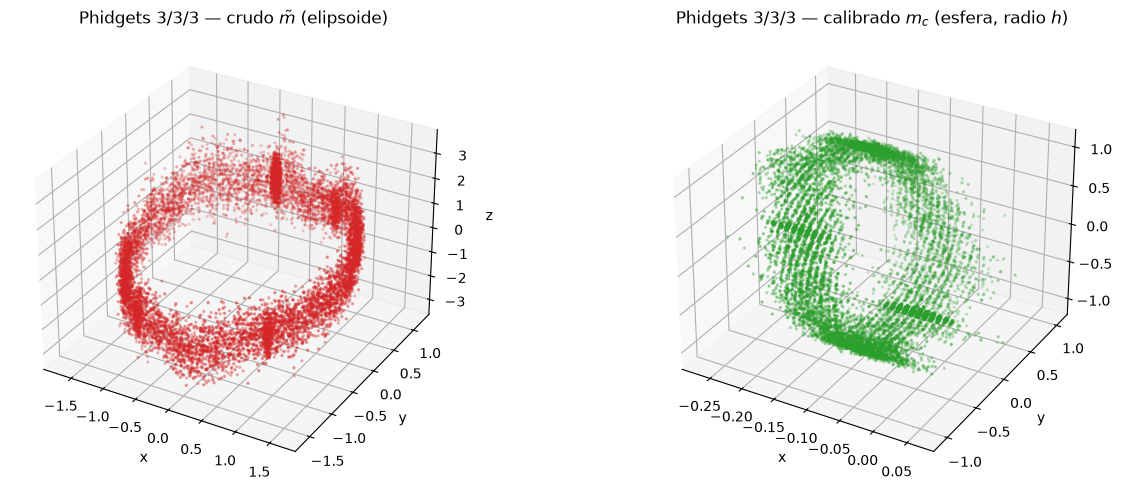

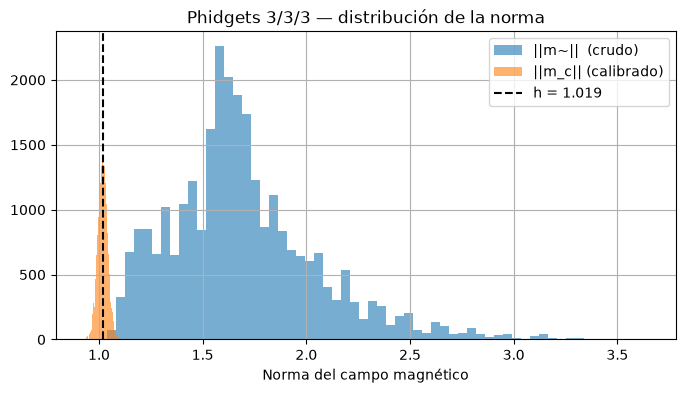

In [256]:
# --- Gráficos: crudo (elipsoide) vs calibrado (esfera) ---
fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(M[:, 0], M[:, 1], M[:, 2], s=2, alpha=0.4, c='tab:red')
ax1.set_title("Phidgets 3/3/3 — crudo $\\tilde{m}$ (elipsoide)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(Mc[:, 0], Mc[:, 1], Mc[:, 2], s=2, alpha=0.4, c='tab:green')
ax2.set_title("Phidgets 3/3/3 — calibrado $m_c$ (esfera, radio $h$)")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
plt.tight_layout(); plt.show()

# Norma antes/después: debe pasar de variable a ~constante = h
plt.figure(figsize=(8, 4))
plt.hist(np.linalg.norm(M, axis=1),  bins=60, alpha=0.6, label="||m~||  (crudo)")
plt.hist(np.linalg.norm(Mc, axis=1), bins=60, alpha=0.6, label="||m_c|| (calibrado)")
plt.axvline(h, color='k', ls='--', label="h = %.3f" % h)
plt.title("Phidgets 3/3/3 — distribución de la norma")
plt.xlabel("Norma del campo magnético"); plt.legend(); plt.grid(True); plt.show()

## Sección 3 — STMicroelectronics LSM9DS1 (`df2`)

Mismo desarrollo sobre el LSM9DS1 (datos en $[G]$): se reescriben las fórmulas $H\theta=y \Rightarrow \hat\theta=(H^TH)^{-1}H^Ty$ y se recuperan $\hat{\mathbf b}_{HI},\ \hat h,\ \hat S_I$.

In [257]:
# ============== Sección 3: STMicroelectronics LSM9DS1 ===============
# Mediciones crudas  m~ = (x, y, z)
try:
    M = df2[['vector.x', 'vector.y', 'vector.z']].to_numpy()
except KeyError:
    M = df2[['magnetic_field.x', 'magnetic_field.y', 'magnetic_field.z']].to_numpy()

x, y, z = M[:, 0], M[:, 1], M[:, 2]

# Vector de regresores  phi_i = [x², y², z², 2xy, 2xz, 2yz, x, y, z]  ->  H (N x 9)
H = np.column_stack([x**2, y**2, z**2, 2*x*y, 2*x*z, 2*y*z, x, y, z])
yv = np.ones(H.shape[0])                       # y = 1_N

# Estimador MSE:  theta_hat = (H^T H)^{-1} H^T y
theta = np.linalg.inv(H.T @ H) @ H.T @ yv
a11, a22, a33, a12, a13, a23, n1, n2, n3 = theta

# Recuperación de parámetros físicos
A = np.array([[a11, a12, a13],
              [a12, a22, a23],
              [a13, a23, a33]])               # A_hat <- theta_1:6  (simétrica)
n = np.array([n1, n2, n3])                     # n_hat <- theta_7:9

b_HI = -0.5 * np.linalg.inv(A) @ n             # b_HI = -1/2 A^{-1} n   (Hard-Iron)
h2   = b_HI @ A @ b_HI + 1.0                   # h² = b_HI^T A b_HI + 1   (d = -1)
h    = np.sqrt(abs(h2))


eigval, R = np.linalg.eigh(A)

if np.any(eigval <= 0):
    print("❌ ERROR CRÍTICO: A no es definida positiva. Los datos son planos o están corruptos.")
    print("Autovalores detectados:", eigval)
    # Forzamos un fallback para que el código no explote (opcional)
    eigval = np.abs(eigval)

# La calibración real utiliza el RECÍPROCO (1 / sqrt(lambda)) para normalizar los ejes
#S_I = R @ np.diag(1.0 / np.sqrt(eigval)) @ R.T
S_I = np.diag(np.sqrt(np.abs(eigval))) @ R.T
# Mediciones calibradas
Mc = (S_I @ (M - b_HI).T).T





STMicroelectronics LSM9DS1
b_HI (hard-iron) = [ 1.20334805 -4.57939806  2.46272916]
h (radio)        = 2.4543154572563384
S_I (soft-iron)  =
 [[-3.88582803e-08  7.67535401e-07  3.45258790e-01]
 [ 7.04609079e-08  3.93640704e-01 -8.75091905e-07]
 [-8.52017106e-01  1.52509165e-07 -9.58933921e-08]]
||m_c|| medio = 2.4543   std = 0.0000


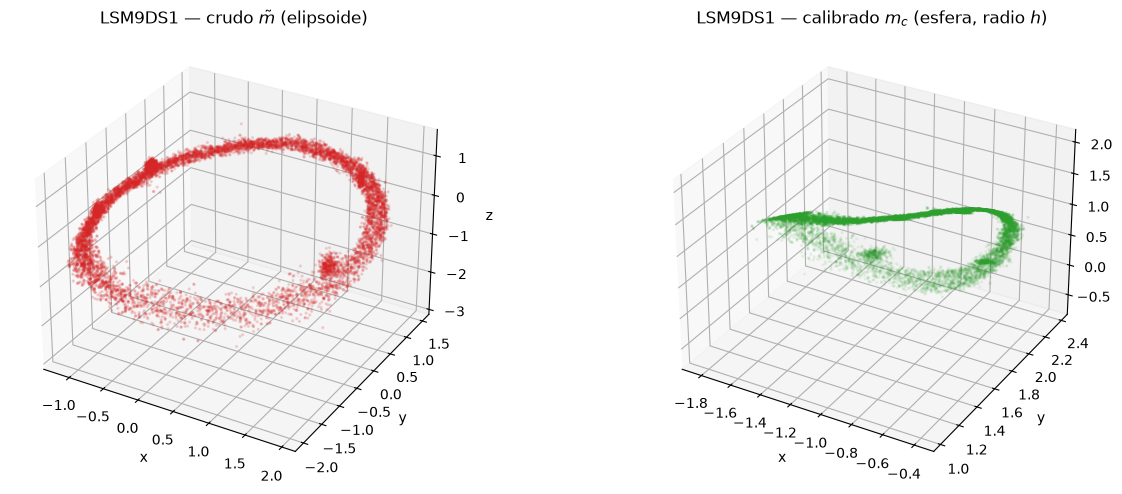

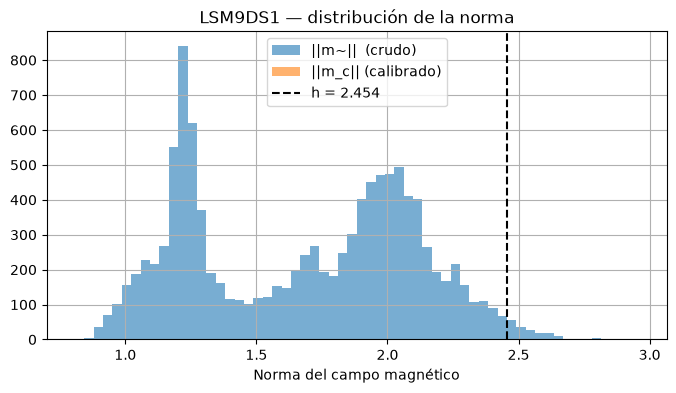

In [258]:

print("STMicroelectronics LSM9DS1")
print("b_HI (hard-iron) =", b_HI)
print("h (radio)        =", h)
print("S_I (soft-iron)  =\n", S_I)
print("||m_c|| medio = %.4f   std = %.4f" % (np.linalg.norm(Mc, axis=1).mean(),
                                             np.linalg.norm(Mc, axis=1).std()))

# --- Gráficos: crudo (elipsoide) vs calibrado (esfera) ---
fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(M[:, 0], M[:, 1], M[:, 2], s=2, alpha=0.4, c='tab:red')
ax1.set_title("LSM9DS1 — crudo $\\tilde{m}$ (elipsoide)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(Mc[:, 0], Mc[:, 1], Mc[:, 2], s=2, alpha=0.4, c='tab:green')
ax2.set_title("LSM9DS1 — calibrado $m_c$ (esfera, radio $h$)")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
plt.tight_layout(); plt.show()

# Norma antes/después: debe pasar de variable a ~constante = h
plt.figure(figsize=(8, 4))
plt.hist(np.linalg.norm(M, axis=1),  bins=60, alpha=0.6, label="||m~||  (crudo)")
plt.hist(np.linalg.norm(Mc, axis=1), bins=60, alpha=0.6, label="||m_c|| (calibrado)")
plt.axvline(h, color='k', ls='--', label="h = %.3f" % h)
plt.title("LSM9DS1 — distribución de la norma")
plt.xlabel("Norma del campo magnético"); plt.legend(); plt.grid(True); plt.show()

# Parte 2 — PCA + elipse 2D: mediciones y reconstrucción

En la Parte 1 el ajuste de **elipsoide 3D** es degenerado para los sensores que giran casi sobre un plano (autovalor negativo en `df0`, `S_I` disparado en `df1`). La solución es proyectar cada nube a su **mejor plano** por PCA (SVD, 2 componentes principales) y ajustar una **elipse 2D** por MSE:

$$a_{11}x^2+a_{22}y^2+2a_{12}xy+n_1x+n_2y=1,\qquad
\boldsymbol\phi_i=[x_i^2,y_i^2,2x_iy_i,x_i,y_i]^T,\quad H\theta=\mathbf 1$$

$$M_2=\begin{bmatrix}a_{11}&a_{12}\\a_{12}&a_{22}\end{bmatrix},\quad
\mathbf b=-\tfrac12 M_2^{-1}\mathbf n,\quad \hat h^2=\mathbf b^TM_2\mathbf b+1$$

Luego se **reconstruye** la elipse ajustada y se grafica:
- **2D:** mediciones proyectadas + contorno de la elipse en el plano.
- **3D:** ese contorno mapeado de vuelta al espacio original, $\;\mathbf p_{3D}=\bar{\mathbf m}+P_{2D}V_{[:2]}$, superpuesto sobre las mediciones crudas $\tilde{\mathbf m}$.

XSens MTi 630                centro=[0.3028 0.1267]  h=1.0154  RMSE(Hθ-1)=3.037e-01  M2>0: sí


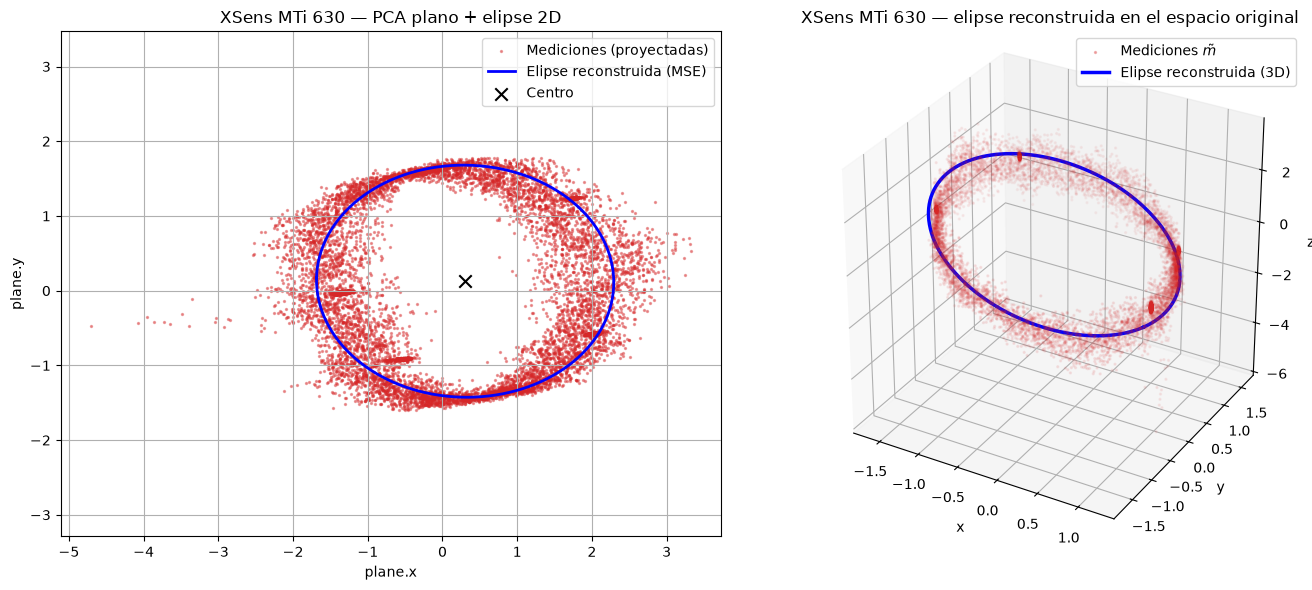

Phidgets 3/3/3               centro=[-0.2989  0.0221]  h=1.0111  RMSE(Hθ-1)=3.352e-01  M2>0: sí


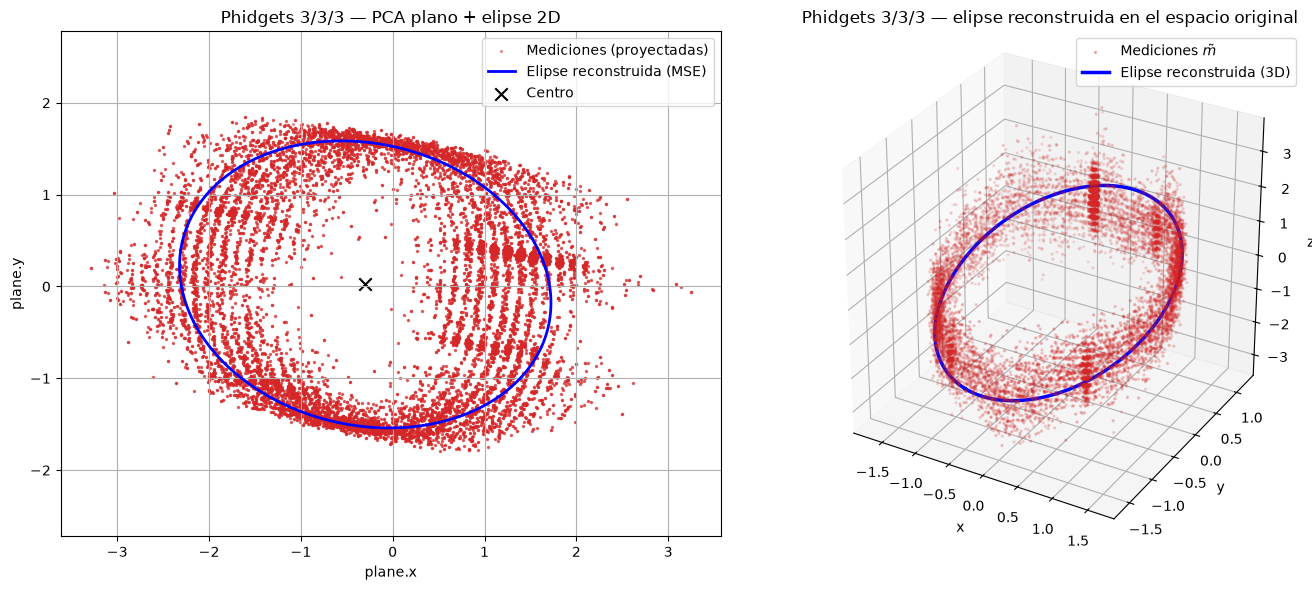

STMicroelectronics LSM9DS1   centro=[ 0.1174 -0.5456]  h=1.0593  RMSE(Hθ-1)=1.390e-01  M2>0: sí


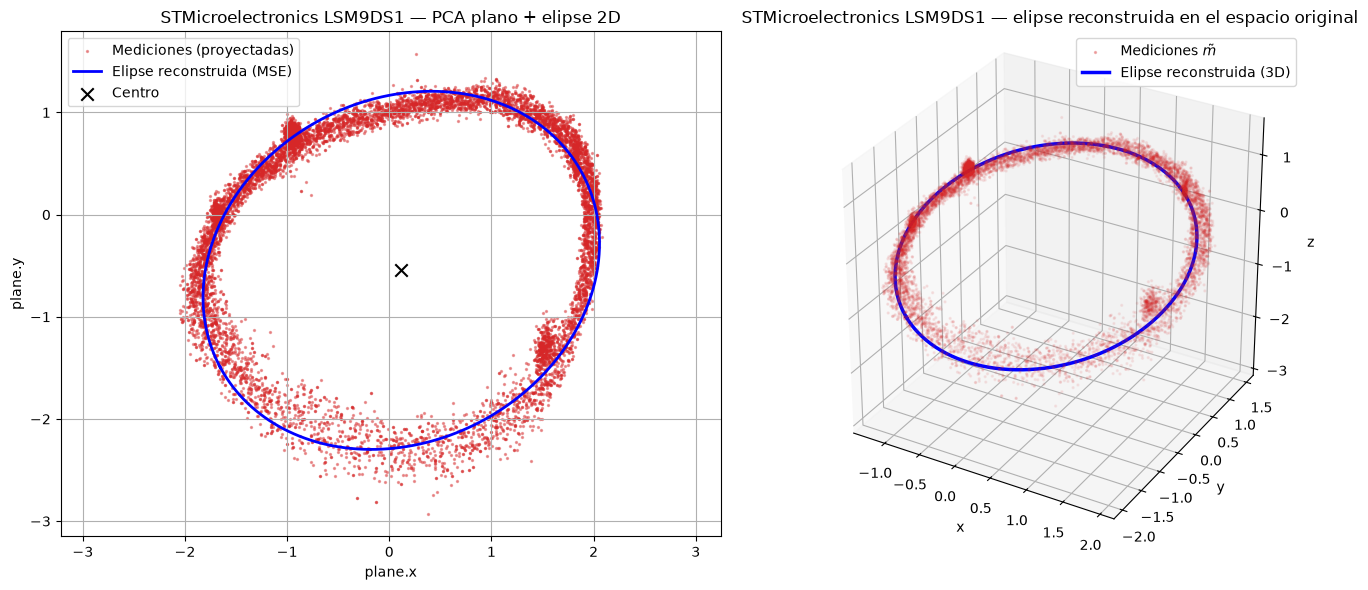

In [259]:
# ===== Parte 2 — PCA + elipse 2D reconstruida (mediciones vs reconstrucción) =====
sensores = [('XSens MTi 630', df0),
            ('Phidgets 3/3/3', df1),
            ('STMicroelectronics LSM9DS1', df2)]

for nombre, df in sensores:
    # Mediciones crudas 3D  m~ = (x, y, z)
    if 'vector.x' in df.columns:
        M3 = df[['vector.x', 'vector.y', 'vector.z']].to_numpy()
    else:
        M3 = df[['magnetic_field.x', 'magnetic_field.y', 'magnetic_field.z']].to_numpy()

    # --- PCA por SVD: mejor plano (2 componentes principales) ---
    center3 = M3.mean(axis=0)
    Xc = M3 - center3
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    P2 = Xc @ Vt[:2].T                 # coordenadas en el plano (plane.x, plane.y)
    x, y = P2[:, 0], P2[:, 1]

    # --- Elipse 2D por MSE:  phi=[x², y², 2xy, x, y],  H theta = 1 ---
    H = np.column_stack([x**2, y**2, 2*x*y, x, y])
    theta = np.linalg.inv(H.T @ H) @ H.T @ np.ones(H.shape[0])
    a11, a22, a12, n1, n2 = theta
    M2 = np.array([[a11, a12],
                   [a12, a22]])
    nvec = np.array([n1, n2])
    b2 = -0.5 * np.linalg.inv(M2) @ nvec        # centro (hard-iron 2D)
    h  = np.sqrt(abs(b2 @ M2 @ b2 + 1.0))       # radio
    eigval, R = np.linalg.eigh(M2)              # M2 = R Λ R^T (definida positiva en el plano)

    # --- Reconstrucción del contorno de la elipse en el plano ---
    t = np.linspace(0, 2*np.pi, 400)
    ell2d = b2.reshape(2, 1) + R @ np.diag(h/np.sqrt(np.abs(eigval))) @ np.vstack([np.cos(t), np.sin(t)])

    # --- Reconstrucción de esa elipse al espacio 3D original:  p3 = center3 + P2d @ Vt[:2] ---
    ell3d = center3 + ell2d.T @ Vt[:2]          # (400, 3)

    # --- Calidad del ajuste (residuo del sistema H theta = 1) ---
    res = H @ theta - 1.0
    pos_def = "sí" if np.all(eigval > 0) else "NO"
    print("%-28s centro=%s  h=%.4f  RMSE(Hθ-1)=%.3e  M2>0: %s"
          % (nombre, np.array2string(b2, precision=4), h,
             np.sqrt((res**2).mean()), pos_def))

    # --- Gráficos: (a) elipse reconstruida 2D, (b) elipse reconstruida en 3D ---
    fig = plt.figure(figsize=(14, 6))

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.scatter(x, y, s=2, alpha=0.4, c='tab:red', label='Mediciones (proyectadas)')
    ax1.plot(ell2d[0], ell2d[1], 'b', lw=2, label='Elipse reconstruida (MSE)')
    ax1.scatter(b2[0], b2[1], c='k', marker='x', s=80, label='Centro')
    ax1.set_title("%s — PCA plano + elipse 2D" % nombre)
    ax1.set_xlabel("plane.x"); ax1.set_ylabel("plane.y")
    ax1.axis('equal'); ax1.grid(True); ax1.legend()

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.scatter(M3[:, 0], M3[:, 1], M3[:, 2], s=2, alpha=0.3, c='tab:red',
                label='Mediciones $\\tilde{m}$')
    ax2.plot(ell3d[:, 0], ell3d[:, 1], ell3d[:, 2], 'b', lw=2.5,
             label='Elipse reconstruida (3D)')
    ax2.set_title("%s — elipse reconstruida en el espacio original" % nombre)
    ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
    ax2.set_box_aspect([1, 1, 1]); ax2.legend()

    plt.tight_layout(); plt.show()